# 12. Stochastic uncertainty with a Gaussian copula

When the parameters aren't just bounded but have probability distributions, the analysis shifts from "worst case" to "statistical summaries." This notebook exercises Monte Carlo sampling with a Gaussian copula glueing two marginals together, and shows how a single solve call returns several summaries at once.

The drone has both `uncertain_set` (a Box) and `uncertain_dist` (a Stochastic with a Gaussian copula) attached to its battery. We ask for both kinds of answers and see how they compare.


## Imports and model

In [1]:
from scipy import stats
from codesign import (
    Box, GaussianCopula, Module, Reals, Stochastic, System, solve,
)

class Battery(Module):
    F = {"capacity": Reals(unit="J")}
    R = {"mass":     Reals(unit="kg")}
    def __init__(self, specific_energy=1.8e6, efficiency=0.85):
        self.specific_energy = specific_energy
        self.efficiency = efficiency
        super().__init__()
    def h(self, f):
        return {"mass": f["capacity"] / (self.specific_energy * self.efficiency)}

class Actuator(Module):
    F = {"lift_force": Reals(unit="N")}
    R = {"power":      Reals(unit="W")}
    def h(self, f):
        return {"power": 10.0 * f["lift_force"] ** 2}

bat = Battery()
# Set-based bracket: the Box gives a deterministic worst-case answer.
bat.uncertain_set = Box(
    specific_energy=(1.6e6, 2.0e6, "more_is_better"),
    efficiency=(0.80, 0.90, "more_is_better"),
)
# Stochastic model: two uniform marginals tied by a Gaussian copula.
# The 0.4 off-diagonal entry means specific_energy and efficiency are
# positively correlated in their joint distribution (good cells tend to
# be efficient too), softening the joint-pessimistic case.
bat.uncertain_dist = Stochastic(
    marginals={
        "specific_energy": stats.uniform(loc=1.6e6, scale=0.4e6),
        "efficiency":      stats.uniform(loc=0.80, scale=0.10),
    },
    copula=GaussianCopula(correlation=[[1.0, 0.4],
                                       [0.4, 1.0]]),
)

# Wiring identical to notebook 07.
sys = System("drone")
endurance     = sys.provides("endurance",     unit="s")
extra_payload = sys.provides("extra_payload", unit="kg")
extra_power   = sys.provides("extra_power",   unit="W")
total_mass    = sys.requires("total_mass",    unit="kg")
b = sys.add("battery",  bat)
a = sys.add("actuator", Actuator())
b.capacity    >= (a.power + extra_power) * endurance
a.lift_force  >= 9.81 * (b.mass + extra_payload)
total_mass    >= b.mass + extra_payload
drone = sys.build()
f = {"endurance": 300.0, "extra_payload": 0.5, "extra_power": 5.0}

## A nominal solve, for reference

In [2]:
nominal = solve(drone, f)
nominal_mass = list(nominal.antichain.points)[0]["total_mass"]
print(f"Nominal mass: {nominal_mass:.4f} kg")

Nominal mass: 0.5602 kg


## All summaries in one call

The solver gathers the deterministic worst case and runs the Monte Carlo for all the statistical summaries in a single pass.


In [3]:
# Each summary in `uncertainty` triggers one piece of work:
#   "worst_case" -> one deterministic solve at the Box corner
#   "mean" / "p95" / "cvar95" -> aggregated over the n_samples MC runs
#   "samples" -> keep the raw antichain per MC sample on res.samples
res = solve(
    drone, f,
    uncertainty=["worst_case", "mean", "p95", "cvar95", "samples"],
    n_samples=1000,
    rng_seed=42,           # for reproducible MC draws
    verbose=1,
)

wc = list(res.worst_case.antichain.points)[0]["total_mass"]
print()
# Canonical ordering: nominal < mean < p95 < CVaR95 < worst_case.
print(f"Worst case (Box):     {wc:.4f} kg")
print(f"Mean:                 {res.mean['total_mass']:.4f} kg")
print(f"95th percentile:      {res.p95['total_mass']:.4f} kg")
print(f"CVaR (worst 5% mean): {res.cvar95['total_mass']:.4f} kg")
print(f"Feasibility rate:     {res.feasibility_rate:.3f}")

[solve] converged: 55 iters, |A|=1, total=1.2ms, feasible=True


[solve] uncertainty: 1000 MC samples, feasibility_rate=1.000

Worst case (Box):     0.5760 kg
Mean:                 0.5613 kg
95th percentile:      0.5729 kg
CVaR (worst 5% mean): 0.5742 kg
Feasibility rate:     1.000


## Visualising the distribution

The raw antichain per MC sample is on `res.samples`. The `codesign.viz` module provides `plot_uncertainty` as a one-liner that draws the histogram and marks each summary statistic.


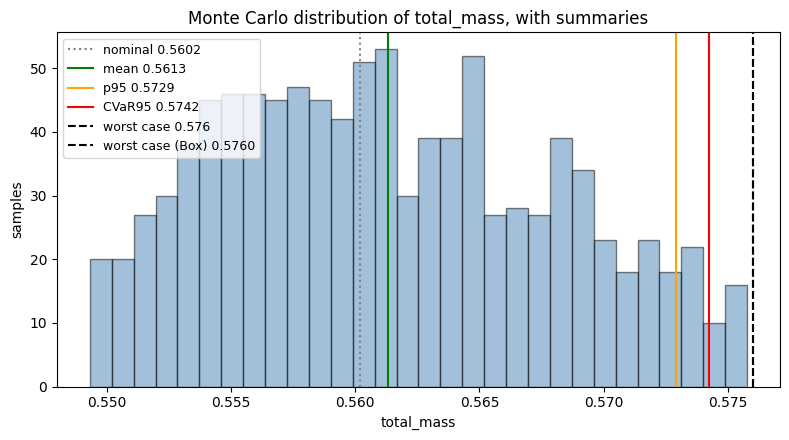

In [4]:
import matplotlib.pyplot as plt
from codesign import viz

ax = viz.plot_uncertainty(res, port="total_mass",
                          nominal=nominal_mass, bins=30)
wc = list(res.worst_case.antichain.points)[0]["total_mass"]
ax.axvline(wc, color="black", linestyle="--",
           label=f"worst case (Box) {wc:.4f}")
ax.legend(loc="upper left", fontsize=9)
ax.set_title("Monte Carlo distribution of total_mass, with summaries")
plt.tight_layout()
plt.show()

## Reading the chart

- **nominal** is what you'd get if you ignored the uncertainty entirely (parameters at their declared centres).
- **mean** is the expected total_mass over the joint distribution. Slightly above nominal because the distribution is skewed (the parameters' product is harmonic-mean-like; small values dominate).
- **p95** is "95% of designs are no heavier than this." Pessimistic but useful for typical specification claims.
- **CVaR95** is "the average mass over the worst 5% of scenarios." Standard for engineering risk.
- **worst case (Box)** is the deterministic upper bound from the set-based analysis. Slightly above CVaR95 because the Box admits the implausible corner.

A natural ordering emerges: `nominal < mean < p95 < CVaR95 < worst_case`. For a normal-design specification you'd usually report the p95 or CVaR95; the worst case is the right answer when failures truly mean disaster.
